# Experiments wrapping sampling functions

This will allow to implement algorithms that require refitting in ArviZ.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

In [2]:
xdata = np.linspace(0,10,20)
b1, b0, sigma = 1, -2, 3
ydata = np.random.normal(loc=b1*xdata + b0, scale=sigma)

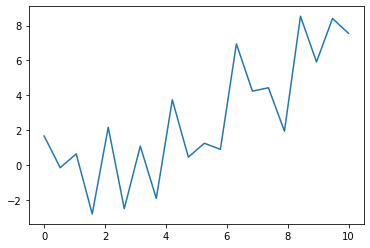

In [3]:
plt.plot(xdata, ydata)

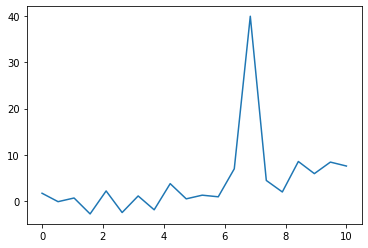

In [4]:
ydata[13] = 40
plt.plot(xdata, ydata)

In [5]:
data_dict = {"N": len(xdata), "x": xdata, "y": ydata}

In [38]:
class SamplingWrapper:
    """Class wrapping sampling routines for its usage via ArviZ.
    
    Using a common class, all inference backends can be supported in ArviZ. Hence, statistical 
    functions requiring refitting like Leave Future Out or Simulation Based Calibration can be
    performed from ArviZ.
    
    Parameters
    ----------
    model
        The model object used for sampling.
    idata_orig: InferenceData, optional
        Original InferenceData object. 
    log_like_fun: callable, optional
        For simple cases where the pointwise log likelihood is a Python function, this function will be used to
        calculate the log likelihood. Otherwise, ``point_log_likelihood`` method must be implemented.
    sample_kwargs: dict, optional
        Sampling kwargs are stored as class attributes for their usage in the ``sample`` method. 
    idata_kwargs: dict, optional
        kwargs are stored as class attributes to be used in the ``get_inference_data`` method.
    """
    
    def __init__(self, model, idata_orig=None, log_like_fun=None, sample_kwargs=None, idata_kwargs=None):
        self.model = model
        
        #if not isinstance(idata_orig, az.InferenceData) or idata_orig is not None:
        #    raise TypeError("idata_orig must be of InferenceData type or None")
        self.idata_orig = idata
        
        if log_like_fun is None or callable(log_like_fun):
            self.log_like_fun = log_like_fun
        else:
            raise TypeError("log_like_fun must be a callable object or None")
            
        self.sample_kwargs = {} if sample_kwargs is None else sample_kwargs
        self.idata_kwargs = {} if idata_kwargs is None else idata_kwargs
            
    def sel_observations(self, idx):
        """Select a subset of the observations in idata_orig. 
        
        Parameters
        ----------
        idx
            Indexes to separate from the rest of the observed data.
            
        Returns
        -------
        modified_observed_data
            Observed data whose index is *not* ``idx``
        excluded_observed_data
            Observed data whose index is ``idx``
            """
        raise NotImplementedError("sel_observations method must be implemented for each subclass")
            
    def sample(self, modified_observed_data):
        """Sample ``self.model`` on the ``modified_observed_data`` subset.
        
        Parameters
        ----------
        modified_observed_data
            Data to fit the model on.
            
        Returns
        -------
        fitted_model
            Result of the fit.
        """
        raise NotImplementedError("sample method must be implemented for each subclass")
        
    def get_inference_data(self, fitted_model):
        """Convert the ``fitted_model`` to an InferenceData object.
        
        Parameters
        ----------
        fitted_model
            Result of the current fit.
            
        Returns
        -------
        idata_current: InferenceData
            InferenceData object containing the samples in ``fitted_model``"""
        raise NotImplementedError("get_inference_data method must be implemented for each subclass")    
        
    def point_log_likelihood(self, observation, parameters):
        """Pointwise log likelihood function.
        
        Parameters
        ----------
        observation
            Pointwise observation on which to calculate the log likelihood
        parameters
            Parameters on which the log likelihood is conditioned.
        
        Returns
        -------
        point_log_likelihood: float
            Value of the log likelihood of ``observation`` given ``parameters`` according to ``self.model``"""
        if self.log_like_fun is None:
            raise NotImplementedError("If log_like_fun is None, point_log_likelihood method must "
                                      "be implemented for each subclass")
        else:
            return self.log_like_fun(observation, parameters)
        
    def _check_implemented_methods(self, methods):
        """Check that all methods listed are implemented.
        
        Not all functions that require refitting need to have all the methods implemented in 
        order to work properly. This function shoulg be used before using the SamplingWrapper and
        its subclasses to get informative error messages.
        
        Parameters
        ----------
        methods: list
            Check all elements in methods are implemented.
        """
        supported_methods = ("sel_observations", "sample", "get_inference_data", "point_log_likelihood")
        bad_methods = [method for method in methods if method not in supported_methods]
        if bad_methods:
            raise ValueError(
                "Not all method(s) in {} supported. Supported methods in SamplingWrapper "
                "subclasses are:{}".format(bad_methods, supported_methods)
                
            )
        not_implemented = []
        for method in supported_methods[:-1]:
            if method in methods:
                try:
                    getattr(self, method)(1)
                except NotImplementedError:
                    not_implemented.append(method)
                except:
                    pass
        if "point_log_likelihood" in methods:
            try:
                self.point_log_likelihood(1, 1)
            except NotImplementedError:
                not_implemented.append("point_log_likelihood")
            except:
                pass
        return not_implemented

# PyStan wrapper

In [39]:
class PyStanSamplingWrapper(SamplingWrapper):
    
    def sel_observations(delf, idx):
        obs_data = self.idata.observed_data
        xdata = obs_data.x.values
        mask = np.full_like(xdata, True)
        mask[idx] = False
        try:
            M = len(idx)
        except TypeError:
            M = 1
        observations = {
            "N": obs_data.N.item()-M,
            "x": xdata[mask],
            "y": obs_data.y.values[mask],
        }
        return obvervations
    
    def sample(self, modified_observed_data, **kwargs):
        fit = self.model.sampling(data=modified_observed_data, **kwargs)
        return fit
    
    def get_inference_data(self, fit, **kwargs):
        idata = az.from_pystan(
            posterior=fit,
            posterior_predictive='y_hat',
            observed_data=['y', 'x', 'N'],
            log_likelihood='log_lik', 
            **kwargs
        )
        return idata

In [8]:
import pystan

In [9]:
lr_code = """
data {
  int<lower=0> N;
  vector[N] x;
  vector[N] y;
}

parameters {
  real b0;
  real b1;
  real<lower=0> sigma_e;
}

model {
  b0 ~ normal(0, 20);
  b1 ~ normal(0, 20);
  for (i in 1:N) {
    y[i] ~ normal(b0 + b1 * x[i], sigma_e);
  }

}

generated quantities {
    vector[N] log_lik;
    vector[N] y_hat;
    for (i in 1:N) {
        log_lik[i] = normal_lpdf(y[i] | b0 + b1 * x[i], sigma_e);
        y_hat[i] = normal_rng(b0 + b1 * x[i], sigma_e);
    }
}"""

In [10]:
sm_lr = pystan.StanModel(model_code=lr_code)
control = {"max_treedepth": 15}

INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_09dd7faf564dc459160a94a727cb0c07 NOW.


In [11]:
fit = sm_lr.sampling(data=data_dict, iter=1500, chains=6, control=control)

In [12]:
idata = az.from_pystan(
    posterior=fit,
    posterior_predictive='y_hat',
    observed_data=['y', 'x', 'N'],
    log_likelihood='log_lik',
)

In [40]:
pystan_wrapper = PyStanSamplingWrapper(sm_lr, idata_orig=idata)

In [41]:
pystan_wrapper._check_implemented_methods(["sample", "point_log_likelihood", "get_inference_dat"])

ValueError: Not all method(s) in ['get_inference_dat'] supported.
Supported methods in SamplingWrapper subclasses are:('sel_observations', 'sample', 'get_inference_data', 'point_log_likelihood')

In [ ]:
def calculate_log_likelihood(posterior, observed_data, lnlike_func):
    shape = (posterior.dims["chain"], posterior.dims["draw"])
    out = np.empty(shape)
    out = az.wrap_xarray_ufunc(posterior, lnlike_func)
    return np.sum(out)


def reloo(idata, model, wrapper, sample_kwargs=None, convert_kwargs=None):
    loo_orig = az.loo(idata, pointwise=True)
    khats = loo_orig.pareto_k
    if np.any(khats>.7):
        sampler = wrapper(model, idata)
        for idx in np.argwhere(khats>.7):
            new_obs = wrapper.sel_observations(idx)
            fit = wrapper.sample(new_obs, **sample_kwargs)
            idata_idx = wrapper.get_inference_data(fit, **convert_kwargs)
            psisloo_subset = az.loo(idata_idx, pointwise=True)
            loo_idx = calculate_log_likelihood()

In [46]:
idata.observed_data.isel(13)

ValueError: the first argument to .isel must be a dictionary

In [13]:
loo = az.loo(idata, pointwise=True)
loo

/home/oriol/Public/arviz/arviz/stats/stats.py:443: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  "Estimated shape parameter of Pareto distribution is greater than 0.7 for "


Computed from 4500 by 20 log-likelihood matrix

       Estimate       SE
IC_loo   152.68    22.67
p_loo      7.42        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)       19   95.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    1    5.0%

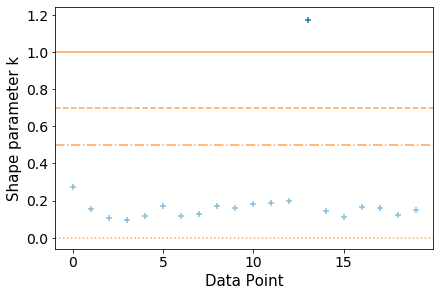

In [16]:
az.plot_khat(loo)

In [17]:
def pystan_refitter(stan_model, data_dict, sampling_kwargs=None, convert_kwargs=None):
    if sampling_kwargs is None:
        sampling_kwargs = {}
    if convert_kwargs is None:
        convert_kwargs = {}
    fit = stan_model.sampling(data=data_dict, **sampling_kwargs)
    idata = az.from_pystan(posterior=fit, **convert_kwargs)
    return idata

In [31]:
sampling_kwargs = {"iter": 1500, "chains": 6, "control": control}
convert_kwargs = {"posterior_predictive": 'y_hat', "observed_data": ['y'], "log_likelihood": 'log_lik'}
data_dict2 = {key: item-1 if not isinstance(item, np.ndarray) else np.concatenate((item[:13], item[14:])) for key, item in data_dict.items()}
idata2 = pystan_refitter(sm_lr, data_dict2, sampling_kwargs=sampling_kwargs, convert_kwargs=convert_kwargs)

In [32]:
az.loo(idata2, pointwise=True)

Computed from 4500 by 19 log-likelihood matrix

       Estimate       SE
IC_loo    96.79     5.83
p_loo      2.79        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)       19  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

# Emcee wrapper

# PyMC wrapper